<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Semanal 8
#### Renzo Villani

### Consignas

### $F(s)=\frac{s⁴+4s²+3}{s(s²+2)}$

Se pide hallar la topología circuital y los valores de los componentes

   a) Síntesis de $Z(s)$ mediante el método de Foster en su versión serie

   b) Síntesis de $Y(s)$ mediante el método de Foster en su versión derivación
   
   c) Síntesis de $Z(s)$ mediante el método de Cauer remoción en infinito
   
   d) Síntesis de $Z(s)$ mediante el método de Cauer remoción en DC
   
   e) Simular $Z(s)$ en LTSpice, observando los cambios de fase y la ley de variación ( pendiente ) de la impedancia total de la red.

<center><img src="./src/img1_TS8.png"  width="700"></center>

2. Sea la siguiente red, pensandolo como una inmitancia $F_{12}$
   <center><img src="./src/img2_TS8.png"  width="500"></center>
   a) Hallar el valor de los componentes sabiendo que satisface la función admitancia propuesta
### $F(s)=\frac{s⁵+18s³+48s}{6s⁴+42s²+48}$

3. Encuentre el valor de los elementos que integran el siguiente circuito y que satisface la función impedancia propuesta:
   <center><img src="./src/img3_TS8.png"  width="700"></center>
### $F(s)=\frac{s²+6s+8}{s²+6s+5}$

**Bonus**

- 💎 Implementar en Python el punto 1 verificando los resultados usando las funciones de pytc2: dibujar_foster_serie ; dibujar_foster_derivacion ; dibujar_cauer_LC;
- 🎓 Simulación circuital del punto 2. Medir la admitancia y explicar comportamiento en DC

### Punto 1

Para la síntesis de funciones de exitación no disipativas contamos extensa baraja de metodos mecánicos. Distintas aplicaciones nos llevan distintos circuitos con las inmitancias deseadas.

<center><img src="./src/img4_TS8.png"  width="800"></center>

<center><img src="./src/img5_TS8.png"  width="800"></center>

<center><img src="./src/img6_TS8.png"  width="800"></center>

Opté por simular en *LTspice* la primera red pedida.
<center><img src="./src/img12_TS8.jpeg"  width="500"></center>

<center><img src="./src/img11_TS8.jpeg"  width="800"></center>

La simulación circuital conside con la dada en la consigna. El Foster serie está bien diseñado.

### Punto 2

Cuando la topología no es estrictamente la que requieren los métodos mecánicos, podemos hacer combinación de herramientas para llegar al diseño. En este caso comienzo aplicando Cauer removiendo a 0 para quedarme con una red carácterística de Foster.

<center><img src="./src/img7_TS8.png"  width="800"></center>

<center><img src="./src/img8_TS8.png"  width="800"></center>

### Punto 3

En este caso la red es disipativa, los métodos anteriores pasan a tener utilidad parcial. Para este caso en particular podemos aplicar Foster RC con el agregado del tanque LC, transformando su residuo negativo en una alternativa positiva, y por tanto realizable.

<center><img src="./src/img9_TS8.png"  width="800"></center>

<center><img src="./src/img10_TS8.png"  width="800"></center>

Con estas condiciones podemos obtener los siguientes valores de componentes para satisfacer la inmitancia.

- $C_1 = 4/3$
- $R_1 = 0.85$
- $R_2 = 0.15$
- $R_3 = 0.75$
- $L_1 = 0.03$

### Bonus 1
Implemento en Python los circuitos del ejercicio 1 con las funciones dadas por la cátedra.

In [6]:
# Importo las librerías para trabajar de acá en adelante.
from pytc2.general import print_subtitle


# Librería de TC2
from pytc2.sintesis_dipolo import foster
from pytc2.dibujar import dibujar_foster_serie, dibujar_foster_derivacion
from pytc2.sintesis_dipolo import cauer_LC
from pytc2.dibujar import dibujar_cauer_LC
from pytc2.general import s

#### Foster serie

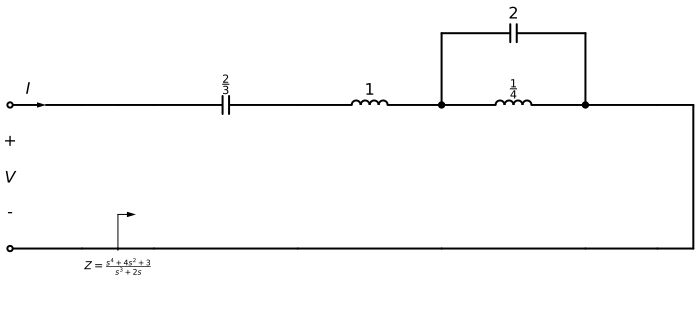

#### Foster derivación

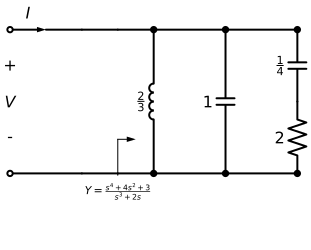

#### Cauer remoción en infiníto

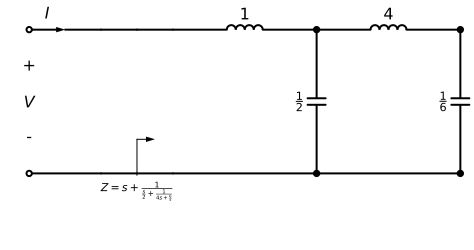

#### Cauer remoción en zero

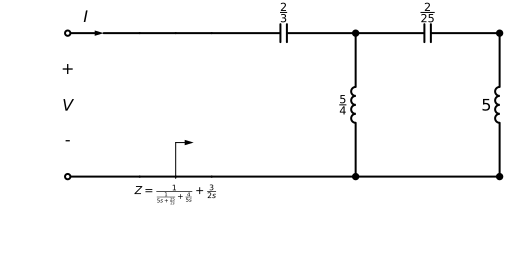

In [10]:
# FF = (s**4 + 4*s**2 + 3)/s*(s**2 + 2)
FF = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)

# --- FOSTER ---

# Se expande FF a la Foster
k0, koo, ki_wi, _, FF_foster = foster(FF)

print_subtitle('Foster serie')
dibujar_foster_serie(k0, koo, ki_wi, z_exc = FF)

print_subtitle('Foster derivación')
dibujar_foster_derivacion(k0, koo, ki_wi, y_exc = FF)


# --- CAUER ---

# Implementaremos FF mediante Cauer con remociones continuas en infinito
koo, F_cauer_oo, rem = cauer_LC(FF, remover_en_inf=True)
print_subtitle('Cauer remoción en infiníto')
dibujar_cauer_LC(koo, z_exc = F_cauer_oo)

# Implementaremos F mediante Cauer con remociones continuas en cero
k0, F_cauer_0, rem = cauer_LC(FF, remover_en_inf=False)
print_subtitle('Cauer remoción en zero')
dibujar_cauer_LC(k0, z_exc = F_cauer_0)

**Los valores de los componentes coinciden con los obtenidos!**

### Bonus 2

Simulo circuitalmente el punto 2.

<center><img src="./src/img13_TS8.jpeg"  width="500"></center>
<center><img src="./src/img14_TS8.jpeg"  width="800"></center>

El comportamiento en DC de la admitancia tiende a 0. Completamente coherente con lo analizado, $Y(s)$ tiene un cero en el origen y por eso este comportamiento.

### Conclusión

En esta tarea se aplicaron varios de los métodos de síntesis de redes a partir de funciones de inmitancia. En el punto 1, la función F(s) resultó ser una función LC realizable (polos y ceros complejos conjugados sobre el eje jω, alternados, con un polo en el origen y otro en infinito). Esto permitió obtener las cuatro topologías: Foster serie y derivación, y Cauer con remoción en infinito y en DC. Todas representan la misma inmitancia con distintos arreglos de L y C, lo que se verificó en LTspice.

En los puntos 2 y 3 se hizo el proceso inverso: identificar los valores de los componentes de una red dada comparando su función con su admitancia o impedancia. A esto sumado que estas redes son pasivas por lo que se tuvo que optar por nuevos métodos.

En definitiva, la tarea permitió consolidar la relación entre la ubicación de polos y ceros, la topología de la red y el comportamiento en frecuencia, y confirmar que una misma función puede tener distintas realizaciones físicas equivalentes. La simulación validó los resultados teóricos.